# ***Renewable Energy Production Forecasting***
## Machine Learning Project
*Author:* Layan Mousa

### Description
This notebook builds a machine learning workflow to forecast renewable energy production. The project includes loading and exploring the dataset, preparing time-based and categorical features, creating a lag feature, visualizing production patterns, training a Random Forest regression model, and evaluating its forecasting performance.

### Dataset
The dataset contains renewable energy production records with information such as date, start hour, end hour, energy source, day, month, season, and production value.

### Project Goal
The goal is to predict the `Production` value using historical, temporal, and categorical information.

---

# **1. Import Libraries**

### Purpose
Import the Python libraries needed for data analysis, visualization, preprocessing, model training, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# **2. Load Dataset**

### Purpose
Load the renewable energy production dataset into a pandas DataFrame.

In [2]:
df = pd.read_csv("Energy Production Dataset.csv")

# **3. Initial Data Exploration**

### Purpose
Display the first rows of the dataset to understand its structure and review the available variables.

In [3]:
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387


## 3.1 Dataset Shape

Display the number of rows and columns in the dataset.

In [4]:
df.shape

(51864, 9)

## 3.2 Feature Names

Display all column names available in the dataset.

In [5]:
df.columns

Index(['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name',
       'Month_Name', 'Season', 'Production'],
      dtype='object')

## 3.3 Data Information

Inspect the data types and non-null values of each column.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB


## 3.4 Missing Values

Check whether the dataset contains missing values before preprocessing.

In [7]:
df.isnull().sum()

Date           0
Start_Hour     0
End_Hour       0
Source         0
Day_of_Year    0
Day_Name       0
Month_Name     0
Season         0
Production     0
dtype: int64

# **4. Feature Engineering**

### Purpose
Create useful time-based and historical features that may improve forecasting performance.

## 4.1 Extract Date Features
Convert the `Date` column to datetime format and extract year, month, and day information.

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df = df.sort_values(["Date", "Start_Hour"]).reset_index(drop=True)

In [11]:
df["Lag_1"] = df["Production"].shift(1)

In [12]:
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production,Year,Month,Day,Lag_1
0,2020-01-01,0,1,Wind,1,Wednesday,January,Winter,3542,2020,1,1,NaN
1,2020-01-01,1,2,Wind,1,Wednesday,January,Winter,2932,2020,1,1,3542.0
2,2020-01-01,2,3,Wind,1,Wednesday,January,Winter,2725,2020,1,1,2932.0
3,2020-01-01,3,4,Wind,1,Wednesday,January,Winter,2761,2020,1,1,2725.0
4,2020-01-01,4,5,Wind,1,Wednesday,January,Winter,2708,2020,1,1,2761.0


In [13]:
df = df.dropna().reset_index(drop=True)

## 4.2 Review the Date Column

Confirm that the date values are stored in the correct datetime format.

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51863 entries, 0 to 51862
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         51863 non-null  datetime64[ns]
 1   Start_Hour   51863 non-null  int64         
 2   End_Hour     51863 non-null  int64         
 3   Source       51863 non-null  object        
 4   Day_of_Year  51863 non-null  int64         
 5   Day_Name     51863 non-null  object        
 6   Month_Name   51863 non-null  object        
 7   Season       51863 non-null  object        
 8   Production   51863 non-null  int64         
 9   Year         51863 non-null  int32         
 10  Month        51863 non-null  int32         
 11  Day          51863 non-null  int32         
 12  Lag_1        51863 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(3), int64(4), object(4)
memory usage: 4.6+ MB


# **5. Exploratory Data Analysis (EDA)**

### Purpose
Visualize renewable energy production patterns and understand how the numerical variables are distributed.

## 5.1 Energy Production Over Time
Display how production changes across the recorded time period.

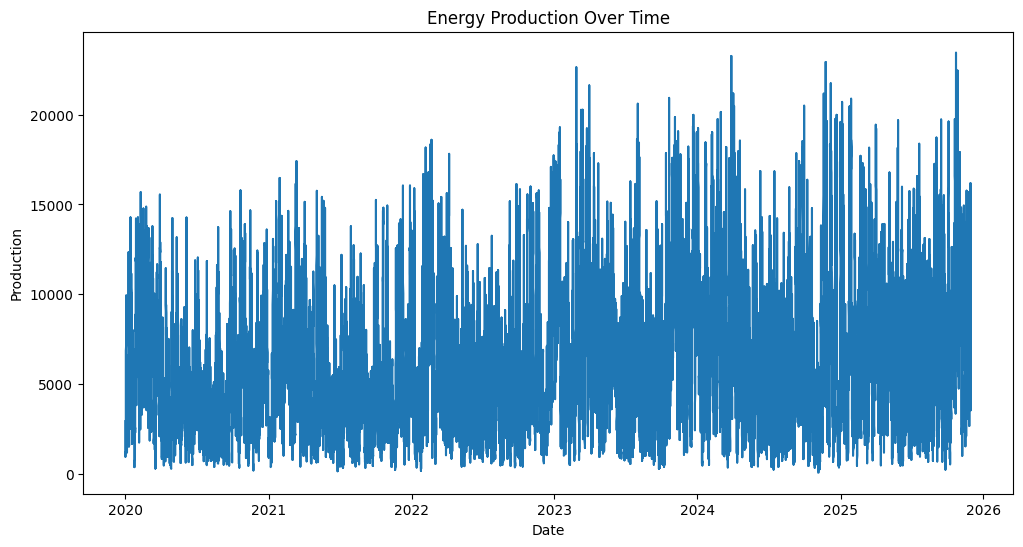

In [16]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Production"])

plt.title("Energy Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")

plt.show()

## 5.2 Distribution of Numerical Features

Display histograms for the numerical variables to understand their distributions.

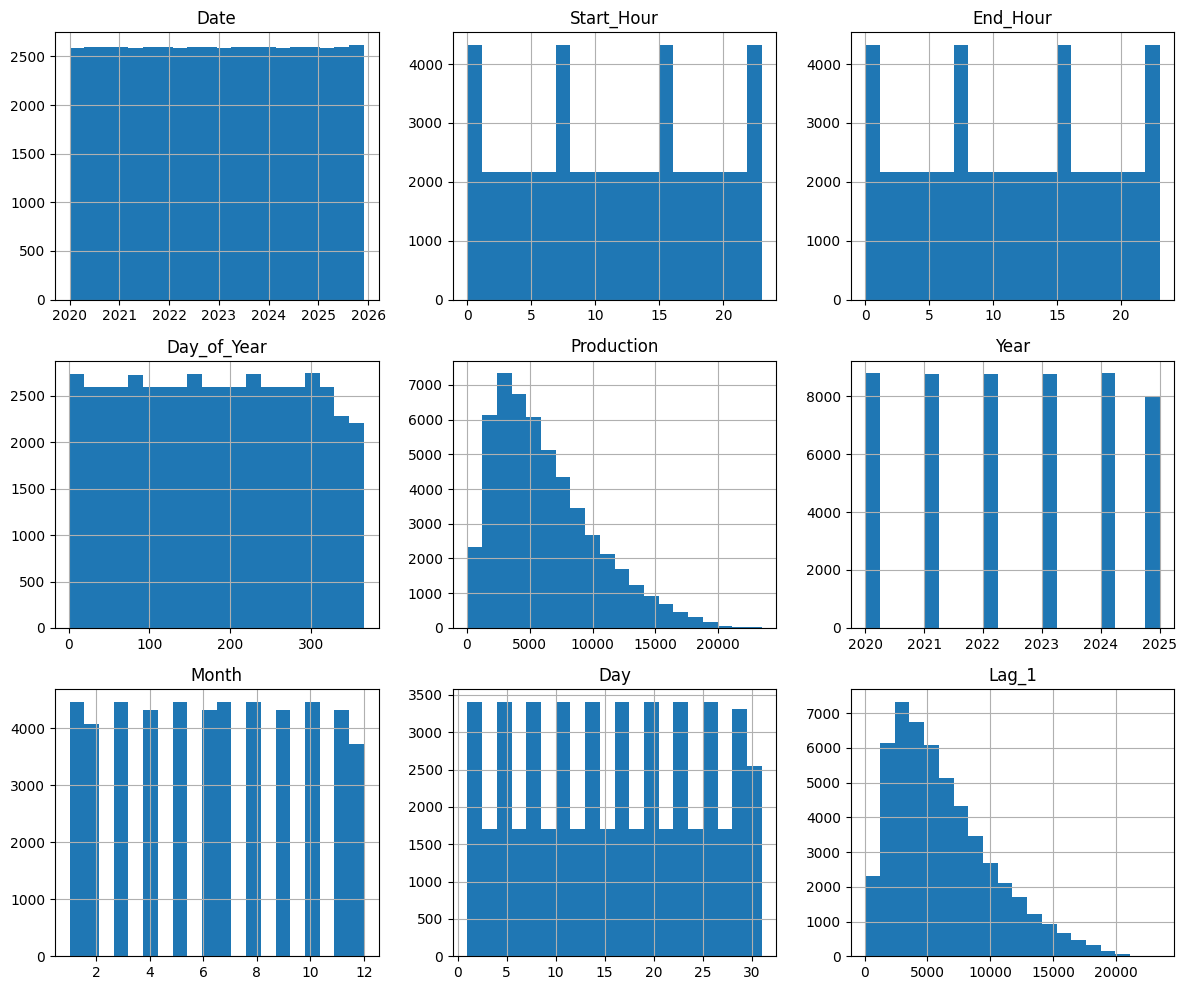

In [17]:

df.hist(figsize=(12,10), bins=20)

plt.tight_layout()

plt.show()

## 5.3 Numerical Feature Distributions

Review the distributions of the numerical columns used in the project.

In [18]:
numeric_df = df.select_dtypes(include=["number"])

## 5.4 Correlation Heatmap

Visualize correlations between numerical features and the production target.

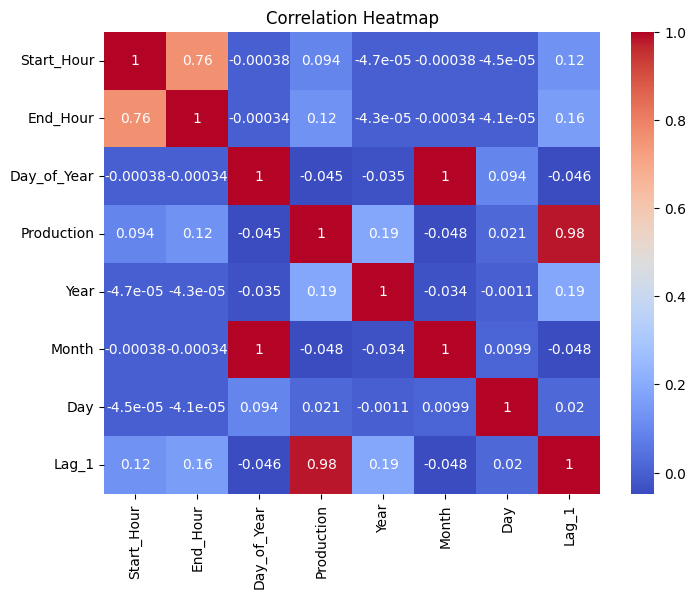

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# **6. Additional Feature Engineering**

### Purpose
Prepare date-derived features for model training and improve the representation of temporal patterns.

In [20]:
df["Date"] = pd.to_datetime(df["Date"])

In [21]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

## 6.1 Remove Original Date Column

Remove the original `Date` column after extracting the required numerical date features.

In [22]:
df.drop("Date", axis=1, inplace=True)

# **7. Data Preprocessing**

### Purpose
Convert categorical variables into numerical values and prepare the dataset for machine learning.

## 7.1 Encode Categorical Features
Use label encoding to transform categorical columns into numerical form.

In [23]:
encoder = LabelEncoder()

df["Source"] = encoder.fit_transform(df["Source"])
df["Day_Name"] = encoder.fit_transform(df["Day_Name"])
df["Month_Name"] = encoder.fit_transform(df["Month_Name"])
df["Season"] = encoder.fit_transform(df["Season"])

In [24]:
X = df.drop(columns=["Production", "Date"], errors="ignore")
y = df["Production"]

# **8. Define Features and Target**

### Purpose
Separate the input features from the target variable and split the data into training and testing sets.

- `X` contains the features used to make predictions.
- `y` contains the renewable energy production values.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **9. Random Forest Regression Model**

### Purpose
Train a Random Forest regressor to learn the relationship between the input features and renewable energy production.

In [26]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [27]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [28]:
y_pred = model.predict(X_test)

## Historical Production vs Model Predictions

This plot compares the actual historical production values with the model predictions on the test dataset.

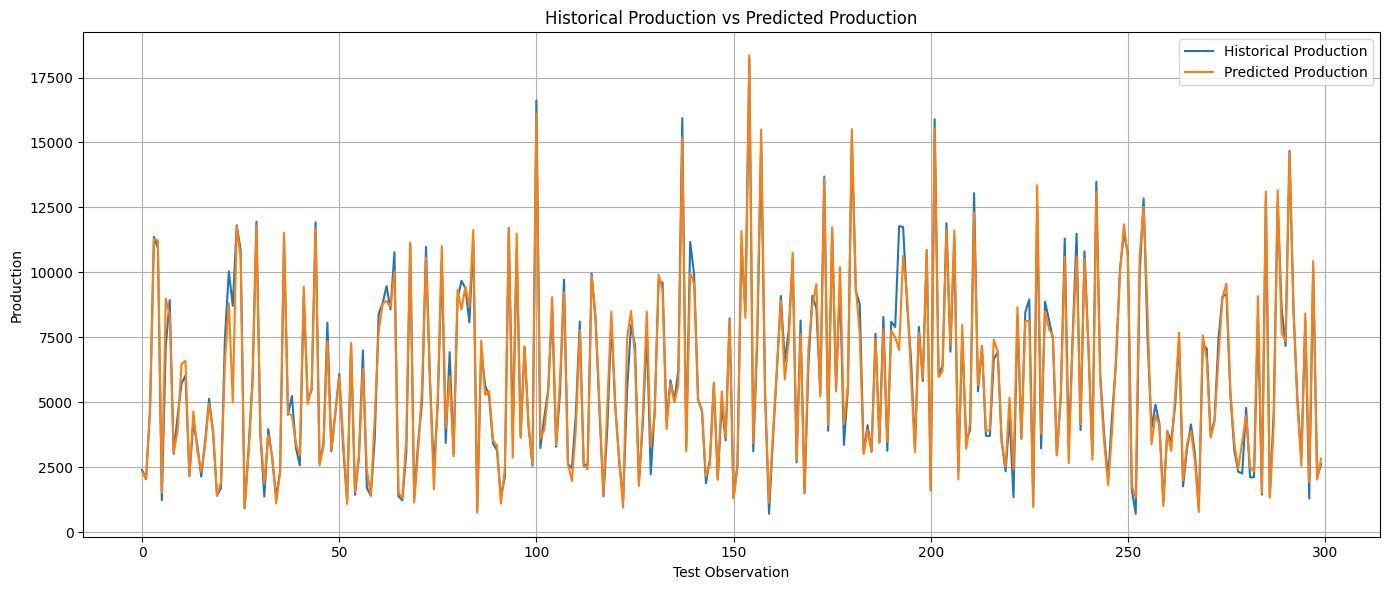

In [ ]:
comparison_df = pd.DataFrame({
    "Historical Production": y_test.reset_index(drop=True),
    "Predicted Production": y_pred
})

plot_sample = comparison_df.head(300)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_sample.index,
    plot_sample["Historical Production"],
    label="Historical Production"
)

plt.plot(
    plot_sample.index,
    plot_sample["Predicted Production"],
    label="Predicted Production"
)

plt.title("Historical Production vs Predicted Production")
plt.xlabel("Test Observation")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
y_pred

array([ 2318.61,  2063.26,  4638.47, ...,  2332.41,  1469.57, 11079.75],
      shape=(10373,))

# **10. Model Evaluation**

### Purpose
Evaluate forecasting performance using RMSE, MAE, and the R² score.

- Lower MAE and RMSE values indicate smaller prediction errors.
- An R² score closer to 1 indicates a stronger fit.

In [31]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

RMSE: 610.7951960312649


In [32]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 377.42883543815674


In [33]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

RMSE: 610.7951960312649


In [34]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9762788767707312


# **11. Actual vs Predicted Values**

### Purpose
Compare the actual production values with the model predictions to visually assess forecasting performance.

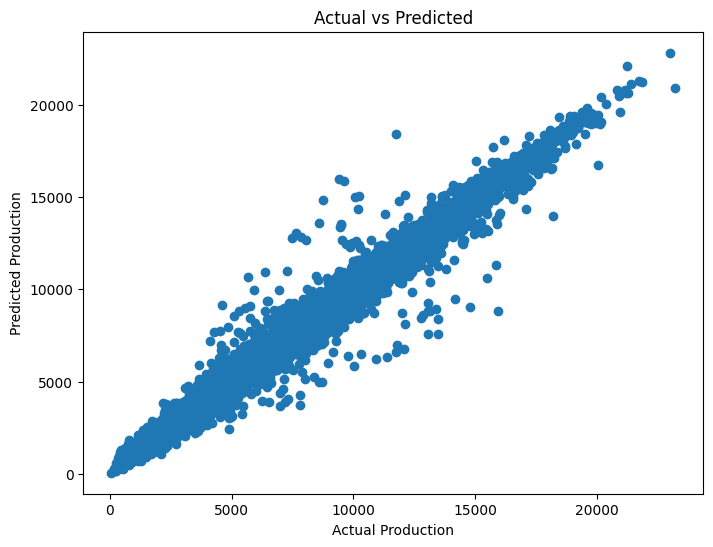

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted")

plt.show()

In [36]:
df["Production"].describe()

count    51863.000000
mean      6215.121474
std       3978.386005
min         58.000000
25%       3111.000000
50%       5372.000000
75%       8501.000000
max      23446.000000
Name: Production, dtype: float64

In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
10,Lag_1,0.968429
1,End_Hour,0.010500
3,Day_of_Year,0.005303
0,Start_Hour,0.004085
9,Day,0.003084
7,Year,0.002518
5,Month_Name,0.001911
4,Day_Name,0.001852
2,Source,0.000884
8,Month,0.000761


# **12. Observations**

Summarize the main patterns identified during data exploration, feature engineering, and model evaluation.

# **13. Conclusion**

This project developed a complete renewable energy forecasting workflow. The dataset was explored and prepared, time-based and categorical features were created, and a `Lag_1` feature was added to provide the model with the previous production value.

A Random Forest regression model was trained and evaluated using MAE, RMSE, and R². The lag feature significantly improved the model by capturing the strong relationship between consecutive production values.